<a href="https://colab.research.google.com/github/Baidunafter/NN/blob/main/%D0%9F%D1%80%D0%B0%D0%BA%D1%82%D0%B8%D1%87%D0%B5%D1%81%D0%BA%D0%B0%D1%8F_%D1%80%D0%B0%D0%B1%D0%BE%D1%82%D0%B0_%E2%84%965_%D0%90%D1%80%D1%85%D0%B8%D1%82%D0%B5%D0%BA%D1%82%D1%83%D1%80%D1%8B_%D0%9D%D0%A1_%D0%B8_Transfer_Learning.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **Практическая работа №5. Архитектуры CNN и Transfer Learning.ipynb**

## **Задание 1. Использование предобученной модели**

### **1.1. Выберите и импортируйте предобученную модель СНС для решения задач классификации из имеющихся в Keras: https://keras.io/api/applications/**

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import cv2
import tensorflow as tf
from tensorflow import keras
from urllib.request import urlopen
from io import BytesIO
from PIL import Image

model = keras.applications.MobileNetV2()
model.summary()

14536120/14536120 ━━━━━━━━━━━━━━━━━━━━ 1s 0us/step


Model: "mobilenetv2_1.00_224"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                  ┃ Output Shape              ┃         Param # ┃ Connected to               ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)      │ (None, 224, 224, 3)       │               0 │ -                          │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ Conv1 (Conv2D)                │ (None, 112, 112, 32)      │             864 │ input_layer[0][0]          │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ bn_Conv1 (BatchNormalization) │ (None, 112, 112, 32)      │             128 │ Conv1[0][0]                │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ Conv1_relu (ReLU)             │ (None, 112, 112, 32)      │               0 │ bn_Conv1[0][0]             │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ expanded_conv_depthwise       │ (None, 112, 112, 32)      │             288 │ Conv1_relu[0][0]           │
│ (DepthwiseConv2D)             │                           │                 │                            │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ expanded_conv_depthwise_BN    │ (None, 112, 112, 32)      │             128 │ expanded_conv_depthwise[0… │
│ (BatchNormalization)          │                           │                 │                            │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ expanded_conv_depthwise_relu  │ (None, 112, 112, 32)      │               0 │ expanded_conv_depthwise_B… │
│ (ReLU)                        │                           │                 │                            │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ expanded_conv_project         │ (None, 112, 112, 16)      │             512 │ expanded_conv_depthwise_r… │
│ (Conv2D)                      │                           │                 │                            │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ expanded_conv_project_BN      │ (None, 112, 112, 16)      │              64 │ expanded_conv_project[0][… │
│ (BatchNormalization)          │                           │                 │                            │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ block_1_expand (Conv2D)       │ (None, 112, 112, 96)      │           1,536 │ expanded_conv_project_BN[… │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ block_1_expand_BN             │ (None, 112, 112, 96)      │             384 │ block_1_expand[0][0]       │
│ (BatchNormalization)          │                           │                 │                            │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ block_1_expand_relu (ReLU)    │ (None, 112, 112, 96)      │               0 │ block_1_expand_BN[0][0]    │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ block_1_pad (ZeroPadding2D)   │ (None, 113, 113, 96)      │               0 │ block_1_expand_relu[0][0]  │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ block_1_depthwise             │ (None, 56, 56, 96)        │             864 │ block_1_pad[0][0]          │
│ (DepthwiseConv2D)             │                           │               

 Total params: 3,538,984 (13.50 MB)

 Trainable params: 3,504,872 (13.37 MB)

 Non-trainable params: 34,112 (133.25 KB)

### **1.2. Загрузите из сети Интернет 5 изображений с разными классами, из тех, что приведены в [списке](https://gist.github.com/yrevar/942d3a0ac09ec9e5eb3a), и сохраните их представление в список images**

In [ ]:
from urllib.request import Request, urlopen

urls = [
    'https://upload.wikimedia.org/wikipedia/commons/thumb/6/66/Siamese_cat_2.jpg/960px-Siamese_cat_2.jpg',
    'https://upload.wikimedia.org/wikipedia/commons/thumb/3/34/2014_Black_Labrador_head_%28mirror%29.jpg/1920px-2014_Black_Labrador_head_%28mirror%29.jpg',
    'https://encrypted-tbn0.gstatic.com/images?q=tbn:ANd9GcQSFmEBb3r7EhX8GwGD60jucbP-V_mAYGwMEw&s',
    'https://upload.wikimedia.org/wikipedia/commons/thumb/3/39/European_Common_Frog_Rana_temporaria.jpg/1280px-European_Common_Frog_Rana_temporaria.jpg',
    'https://encrypted-tbn0.gstatic.com/images?q=tbn:ANd9GcRWrIwendpPFf6S9lRsil3JnPdFgBuRNZDACA&s'
]

images = []

for url in urls:
    req = Request(url, headers={'User-Agent': 'Mozilla/5.0'})
    with urlopen(req) as response:
        arr = np.asarray(bytearray(response.read()), dtype=np.uint8)
    img = cv2.imdecode(arr, -1)
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    images.append(img)

for i, img in enumerate(images):
    print(f"Image {i+1} shape: {img.shape}")

Image 1 shape: (1445, 960, 3)
Image 2 shape: (1281, 1920, 3)
Image 3 shape: (201, 251, 3)
Image 4 shape: (800, 1280, 3)
Image 5 shape: (194, 259, 3)


### **1.3. Напишите функцию, принимающую на вход список с исходными изображениями и возвращающую список с преобразованными изображениями под формат входных данных выбранной Вами модели СНС (нормализация).**

(Не забудьте создать независимую копию исходного списка в теле функции, для обработки именно независимой копии, а не оригинального списка)

In [ ]:
def preprocess_images(images_list):
    processed = []
    for img in images_list:
        img_copy = img.copy()
        img_resized = cv2.resize(img_copy, (224, 224))
        img_array = np.expand_dims(img_resized, axis=0).astype(np.float32)
        img_preprocessed = keras.applications.mobilenet_v2.preprocess_input(img_array)
        processed.append(img_preprocessed)
    return processed

### **1.5. Выведите изображения и соответствующие им классы (как в примере из теории)**

35363/35363 ━━━━━━━━━━━━━━━━━━━━ 0s 1us/step


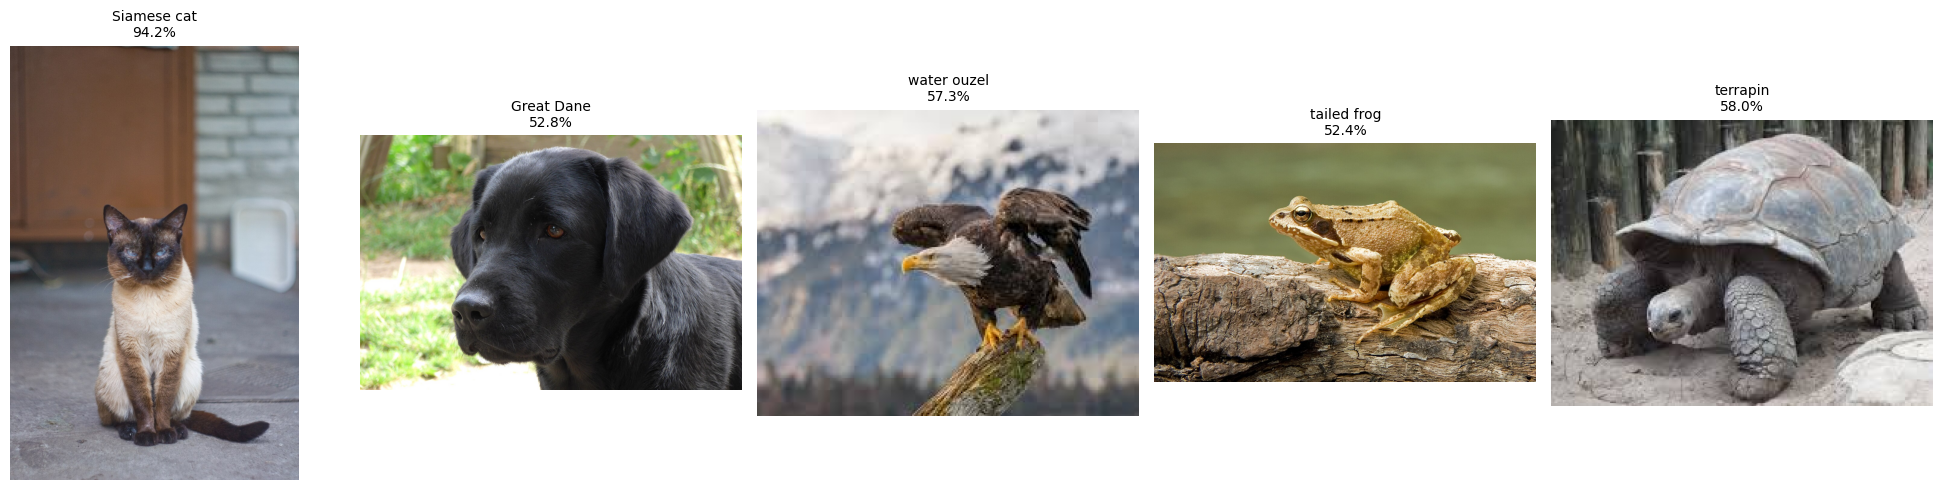

In [ ]:
processed_images = preprocess_images(images)

fig, axes = plt.subplots(1, 5, figsize=(20, 5))
for i, (orig_img, proc_img) in enumerate(zip(images, processed_images)):
    preds = model.predict(proc_img, verbose=0)
    top_preds = keras.applications.mobilenet_v2.decode_predictions(preds, top=1)[0]
    label = top_preds[0][1].replace('_', ' ')
    confidence = top_preds[0][2]

    axes[i].imshow(orig_img)
    axes[i].set_title(f"{label}\n{confidence:.1%}", fontsize=10)
    axes[i].axis('off')

plt.tight_layout()
plt.show()

## **Задание 2. Использование обученной модели для работы со своим датасетом**

### **2.1. Выберите и импортируйте предобученную модель СНС для решения задач классификации из имеющихся в Keras: https://keras.io/api/applications/**

In [ ]:
import os
import random
import numpy as np
import cv2
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Flatten, Dropout, GlobalAveragePooling2D
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import ModelCheckpoint, EarlyStopping, ReduceLROnPlateau
from tensorflow.keras.applications.resnet50 import preprocess_input
from imutils import paths
from collections import Counter
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split
import kagglehub

# from google.colab import drive
# drive.mount('/content/drive')

# SAVE_DIR = '/content/drive/MyDrive/NN_5'
# os.makedirs(SAVE_DIR, exist_ok=True)

SAVE_DIR = 'NN_5'
os.makedirs(SAVE_DIR, exist_ok=True)

IMG_HEIGHT, IMG_WIDTH = 224, 224
BATCH_SIZE = 32
AUTOTUNE = tf.data.AUTOTUNE
NUM_CLASSES = 3

In [ ]:
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
from tensorflow.keras.applications import ResNet50
from tensorflow.keras.applications.resnet50 import preprocess_input
from tensorflow.keras.models import Sequential
from tensorflow.keras.optimizers import Adam
import matplotlib.pyplot as plt
import numpy as np
import pathlib

base_model = ResNet50(weights='imagenet', include_top=False, input_shape=(224, 224, 3), pooling='avg')
base_model.trainable = False  # замораживаем веса

94765736/94765736 ━━━━━━━━━━━━━━━━━━━━ 4s 0us/step


### **2.2. Подготовка тренировочных данных. Разделение на обучающую и тестовую выборку**

In [ ]:
import kagglehub
import os
import random
import numpy as np
import cv2
from imutils import paths
from collections import Counter

dataset_path = kagglehub.dataset_download("alessiocorrado99/animals10")
print("Path to dataset files:", dataset_path)

raw_dir = os.path.join(dataset_path, 'raw-img')

translate = {"cane": "dog", "cavallo": "horse", "elefante": "elephant", "farfalla": "butterfly",
             "gallina": "chicken", "gatto": "cat", "mucca": "cow", "pecora": "sheep",
             "scoiattolo": "squirrel", "dog": "cane", "horse": "cavallo", "elephant": "elefante",
             "butterfly": "farfalla", "chicken": "gallina", "cat": "gatto", "cow": "mucca",
             "spider": "ragno", "squirrel": "scoiattolo"}

selected_classes_en = ["cat", "dog", "horse"]

italian_to_english = {it: en for it, en in translate.items() if en in selected_classes_en}

data = []
labels = []
target_size = (224, 224)
min_count = 1000

for folder_name in os.listdir(raw_dir):
    folder_path = os.path.join(raw_dir, folder_name)
    if not os.path.isdir(folder_path):
        continue

    en_name = italian_to_english.get(folder_name)
    if en_name is None:
        continue

    image_paths = list(paths.list_images(folder_path))
    random.shuffle(image_paths)

    count = 0
    for img_path in image_paths:
        if count >= min_count:
            break
        image = cv2.imread(img_path)
        if image is None:
            continue
        image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)
        image = cv2.resize(image, target_size)
        image = image.astype("float32") / 255.0
        data.append(image)
        labels.append(en_name)
        count += 1

print(f"\nВсего загружено изображений: {len(data)}")
print("Распределение по классам:")
print(Counter(labels))

selected_brands = selected_classes_en
class_names_loaded = sorted(set(labels))
print("Классы:", class_names_loaded)

100%|█████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 586M/586M [00:21<00:00, 28.3MB/s]

Extracting files...


Path to dataset files: C:\Users\Baidunafter\.cache\kagglehub\datasets\alessiocorrado99\animals10\versions\2

Всего загружено изображений: 3000
Распределение по классам:
Counter({'dog': 1000, 'horse': 1000, 'cat': 1000})
Классы: ['cat', 'dog', 'horse']


In [ ]:
le = LabelEncoder()
labels_encoded = le.fit_transform(labels)
class_names = le.classes_
print("Классы:", class_names)

data = np.array(data)

X_train, X_test, y_train, y_test = train_test_split(
    data, labels_encoded, test_size=0.2, random_state=42, stratify=labels_encoded
)
X_train, X_val, y_train, y_val = train_test_split(
    X_train, y_train, test_size=0.1, random_state=42, stratify=y_train
)

print(f"Train: {len(X_train)}, Val: {len(X_val)}, Test: {len(X_test)}")

def make_dataset(X, y, shuffle=False):
    ds = tf.data.Dataset.from_tensor_slices((X, y))
    if shuffle:
        ds = ds.shuffle(buffer_size=len(X))
    ds = ds.map(
        lambda img, lbl: (preprocess_input(tf.cast(img * 255.0, tf.float32)), lbl),
        num_parallel_calls=AUTOTUNE
    )
    ds = ds.batch(BATCH_SIZE).cache().prefetch(AUTOTUNE)
    return ds

train_ds = make_dataset(X_train, y_train, shuffle=True)
val_ds   = make_dataset(X_val,   y_val)
test_ds  = make_dataset(X_test,  y_test)

Классы: ['cat' 'dog' 'horse']
Train: 2160, Val: 240, Test: 600


### **2.3. Обучение своей модели на основе предобученной модели** "*название модели, выбранной в п.2.1.*"

In [ ]:
base_model = tf.keras.applications.ResNet50(
    include_top=False,
    input_shape=(224, 224, 3),
    pooling='avg',
    weights='imagenet'
)
base_model.trainable = False

my_model = Sequential([
    base_model,
    Dense(256, activation='relu'),
    Dropout(0.4),
    Dense(NUM_CLASSES, activation='softmax')
])

my_model.compile(
    optimizer=Adam(learning_rate=1e-3),
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)
my_model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ resnet50 (Functional)                │ (None, 2048)                │      23,587,712 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense (Dense)                        │ (None, 256)                 │         524,544 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout (Dropout)                    │ (None, 256)                 │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_1 (Dense)                      │ (None, 3)                   │             771 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 24,113,027 (91.98 MB)

 Trainable params: 525,315 (2.00 MB)

 Non-trainable params: 23,587,712 (89.98 MB)

In [ ]:
MODEL_PATH = os.path.join(SAVE_DIR, 'best_resnet50.keras')

In [ ]:
checkpoint = ModelCheckpoint(
    MODEL_PATH,
    monitor='val_accuracy',
    save_best_only=True,
    mode='max',
    verbose=1
)
early_stop = EarlyStopping(
    monitor='val_accuracy',
    patience=10,
    restore_best_weights=True,
    verbose=1
)
reduce_lr = ReduceLROnPlateau(
    monitor='val_accuracy',
    factor=0.2,
    patience=3,
    min_lr=1e-7,
    verbose=1
)

history = my_model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=30,
    callbacks=[checkpoint, early_stop, reduce_lr]
)

print(f"Модель сохранена: {MODEL_PATH}")

Epoch 1/30
68/68 ━━━━━━━━━━━━━━━━━━━━ 0s 320ms/step - accuracy: 0.8345 - loss: 0.4587
Epoch 1: val_accuracy improved from None to 0.95833, saving model to NN_5\best_resnet50.keras

Epoch 1: finished saving model to NN_5\best_resnet50.keras
68/68 ━━━━━━━━━━━━━━━━━━━━ 28s 375ms/step - accuracy: 0.9208 - loss: 0.2292 - val_accuracy: 0.9583 - val_loss: 0.0931 - learning_rate: 0.0010
Epoch 2/30
68/68 ━━━━━━━━━━━━━━━━━━━━ 0s 319ms/step - accuracy: 0.9790 - loss: 0.0653
Epoch 2: val_accuracy improved from 0.95833 to 0.96667, saving model to NN_5\best_resnet50.keras

Epoch 2: finished saving model to NN_5\best_resnet50.keras
68/68 ━━━━━━━━━━━━━━━━━━━━ 24s 360ms/step - accuracy: 0.9796 - loss: 0.0634 - val_accuracy: 0.9667 - val_loss: 0.0956 - learning_rate: 0.0010
Epoch 3/30
68/68 ━━━━━━━━━━━━━━━━━━━━ 0s 320ms/step - accuracy: 0.9875 - loss: 0.0331
Epoch 3: val_accuracy did not improve from 0.96667
68/68 ━━━━━━━━━━━━━━━━━━━━ 24s 356ms/step - accuracy: 0.9833 - loss: 0.0417 - val_accuracy: 0.94

In [ ]:
def load_best_model(path):
    model = tf.keras.models.load_model(path)
    print(f"Модель загружена: {path}")
    return model

my_model = load_best_model(MODEL_PATH)

Модель загружена: NN_5\best_resnet50.keras


### **2.4. Визуализация процесса обучения модели**

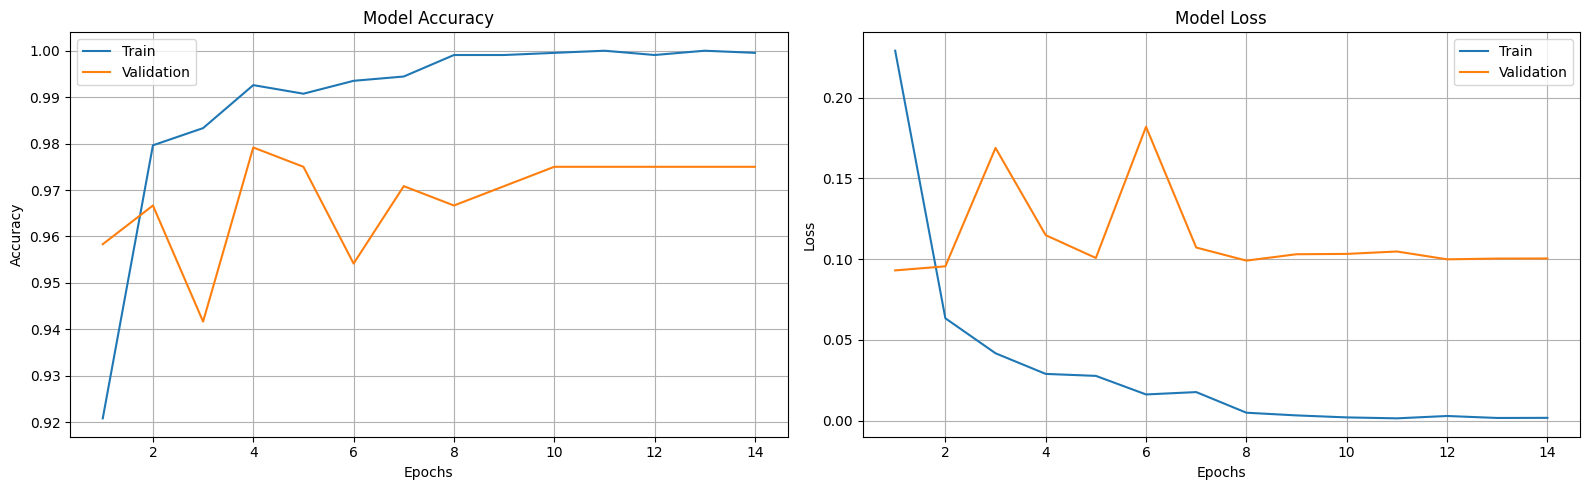

In [ ]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 5))
epochs_range = range(1, len(history.history['accuracy']) + 1)

ax1.plot(epochs_range, history.history['accuracy'], label='Train')
ax1.plot(epochs_range, history.history['val_accuracy'], label='Validation')
ax1.set_title('Model Accuracy')
ax1.set_xlabel('Epochs')
ax1.set_ylabel('Accuracy')
ax1.legend()
ax1.grid(True)

ax2.plot(epochs_range, history.history['loss'], label='Train')
ax2.plot(epochs_range, history.history['val_loss'], label='Validation')
ax2.set_title('Model Loss')
ax2.set_xlabel('Epochs')
ax2.set_ylabel('Loss')
ax2.legend()
ax2.grid(True)

plt.tight_layout()
plt.show()

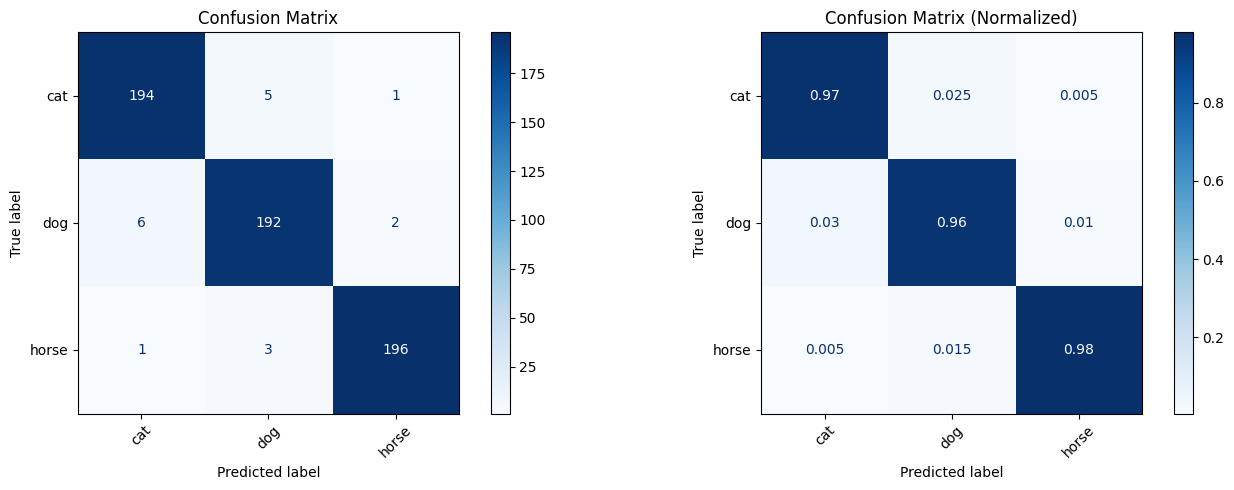

In [ ]:
from sklearn.metrics import classification_report, ConfusionMatrixDisplay

test_loss, test_acc = my_model.evaluate(test_ds, verbose=0)

y_true, y_pred = [], []
for images, labels in test_ds:
    preds = my_model.predict(images, verbose=0)
    y_pred.extend(np.argmax(preds, axis=1))
    y_true.extend(labels.numpy())

y_true = np.array(y_true)
y_pred = np.array(y_pred)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))
ConfusionMatrixDisplay.from_predictions(
    y_true, y_pred, display_labels=class_names, cmap='Blues', ax=ax1)
ax1.set_title('Confusion Matrix')
ax1.grid(False)
ax1.tick_params(axis='x', rotation=45)

ConfusionMatrixDisplay.from_predictions(
    y_true, y_pred, display_labels=class_names, cmap='Blues', normalize='true', ax=ax2)
ax2.set_title('Confusion Matrix (Normalized)')
ax2.grid(False)
ax2.tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

### **2.5. Подготовьте набор проверочных данных (examples)**

In [ ]:
my_model = load_best_model(MODEL_PATH)

my_model.layers[0].trainable = True
for layer in my_model.layers[0].layers[:-30]:
    layer.trainable = False

Модель загружена: NN_5\best_resnet50.keras


In [ ]:
MODEL_PATH_FT = os.path.join(SAVE_DIR, 'best_resnet50_finetuned.keras')

In [ ]:
checkpoint_ft = ModelCheckpoint(
    MODEL_PATH_FT,
    monitor='val_accuracy',
    save_best_only=True,
    mode='max',
    verbose=1
)
early_stop_ft = EarlyStopping(
    monitor='val_accuracy',
    patience=8,
    restore_best_weights=True,
    verbose=1
)
reduce_lr_ft = ReduceLROnPlateau(
    monitor='val_accuracy',
    factor=0.2,
    patience=3,
    min_lr=1e-8,
    verbose=1
)

my_model.compile(
    optimizer=Adam(learning_rate=1e-5),
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

history_ft = my_model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=20,
    callbacks=[checkpoint_ft, early_stop_ft, reduce_lr_ft]
)

print(f"Fine-tuned модель сохранена: {MODEL_PATH_FT}")

Epoch 1/20
68/68 ━━━━━━━━━━━━━━━━━━━━ 0s 536ms/step - accuracy: 0.9798 - loss: 0.0441
Epoch 1: val_accuracy improved from None to 0.97083, saving model to NN_5\best_resnet50_finetuned.keras

Epoch 1: finished saving model to NN_5\best_resnet50_finetuned.keras
68/68 ━━━━━━━━━━━━━━━━━━━━ 52s 630ms/step - accuracy: 0.9856 - loss: 0.0387 - val_accuracy: 0.9708 - val_loss: 0.0985 - learning_rate: 1.0000e-05
Epoch 2/20
68/68 ━━━━━━━━━━━━━━━━━━━━ 0s 554ms/step - accuracy: 0.9954 - loss: 0.0137
Epoch 2: val_accuracy did not improve from 0.97083
68/68 ━━━━━━━━━━━━━━━━━━━━ 41s 606ms/step - accuracy: 0.9958 - loss: 0.0139 - val_accuracy: 0.9708 - val_loss: 0.1038 - learning_rate: 1.0000e-05
Epoch 3/20
68/68 ━━━━━━━━━━━━━━━━━━━━ 0s 545ms/step - accuracy: 0.9994 - loss: 0.0068
Epoch 3: val_accuracy did not improve from 0.97083
68/68 ━━━━━━━━━━━━━━━━━━━━ 40s 593ms/step - accuracy: 0.9995 - loss: 0.0070 - val_accuracy: 0.9625 - val_loss: 0.1137 - learning_rate: 1.0000e-05
Epoch 4/20
68/68 ━━━━━━━━━━━

In [ ]:
def load_best_model(path):
    model = tf.keras.models.load_model(path)
    print(f"Модель загружена: {path}")
    return model

my_model = load_best_model(MODEL_PATH_FT)

test_loss, test_acc = my_model.evaluate(test_ds, verbose=0)
print(f"Fine-tuned | Test accuracy: {test_acc:.4f}  |  Test loss: {test_loss:.4f}")

Модель загружена: NN_5\best_resnet50_finetuned.keras
Fine-tuned | Test accuracy: 0.9733  |  Test loss: 0.0814


### **2.6. Реализуйте графический интерфейс для взаимодействия с обученной моделью, используя [Gradio](https://www.gradio.app/guides/image-classification-in-tensorflow) или люое другое решение.**



Если выбрали Gradio, то в качестве примеров (параметр examples в Gradio), используйте изображения из списка images (п.1.2.)

In [ ]:
#!pip install gradio -q

In [ ]:
import gradio as gr

my_model = load_best_model(MODEL_PATH_FT)

def predict_car(image):
    img = cv2.resize(image, (224, 224)).astype(np.float32)
    img = preprocess_input(img)
    img = np.expand_dims(img, axis=0)
    preds = my_model.predict(img, verbose=0)[0]
    return {class_names[i]: float(preds[i]) for i in range(NUM_CLASSES)}

example_images = []
for brand in selected_brands:
    brand_dir = os.path.join(dataset_path, brand)
    img_paths = list(paths.list_images(brand_dir))[:1]
    if img_paths:
        example_images.append(img_paths[0])

demo = gr.Interface(
    fn=predict_car,
    inputs=gr.Image(type="numpy", label="Загрузите фото"),
    outputs=gr.Label(num_top_classes=NUM_CLASSES),
    title="Классификация животных",
    description=f"Модель определяет вид животного: {', '.join(class_names)}",
    examples=example_images
)

demo.launch(share=True)

Модель загружена: NN_5\best_resnet50_finetuned.keras
* Running on local URL:  http://127.0.0.1:7860
* Running on public URL: https://c9cd7509891202c7fe.gradio.live

This share link expires in 1 week. For free permanent hosting and GPU upgrades, run `gradio deploy` from the terminal in the working directory to deploy to Hugging Face Spaces (https://huggingface.co/spaces)


## **Задание 3. Классификация набора пространственных данных EuroSat (для магистров)**

- Ссылка на датасет: https://github.com/phelber/eurosat

- Описание на kaggle: https://www.kaggle.com/datasets/apollo2506/eurosat-dataset

В этом задании Вам будет предоставлен набор данных EuroSat, который содержит снимки земной поверхности, снятые спутником Sentinel-2. Вам нужно будет обучить модель для классификации этих изображений на 10 классов, представляющих различные типы земного покрова.

### **3.1. Загрузка данных:**
  * [Скачайте](https://madm.dfki.de/files/sentinel/EuroSAT.zip) набор данных EuroSat
  * Разделите данные на обучающую, валидационную и тестовую выборки.



In [ ]:
import os
import zipfile
import pathlib
import urllib.request
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras.callbacks import ModelCheckpoint, EarlyStopping, ReduceLROnPlateau
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.applications.resnet50 import preprocess_input as resnet_preprocess
from tensorflow.keras.applications.vgg16 import preprocess_input as vgg_preprocess
from sklearn.metrics import classification_report, ConfusionMatrixDisplay
#from google.colab import drive

# drive.mount('/content/drive')

# SAVE_DIR = '/content/drive/MyDrive/NN_5'
# os.makedirs(SAVE_DIR, exist_ok=True)

SAVE_DIR = 'NN_5'
os.makedirs(SAVE_DIR, exist_ok=True)

IMG_HEIGHT, IMG_WIDTH = 128, 128
BATCH_SIZE = 16
AUTOTUNE = tf.data.AUTOTUNE
SEED = 42

In [ ]:
!pip install kagglehub -q

import kagglehub
dataset_path = kagglehub.dataset_download("apollo2506/eurosat-dataset")
print("Path:", dataset_path)

import pathlib
data_dir = pathlib.Path(dataset_path)
print("Классы:", [d.name for d in sorted(data_dir.iterdir()) if d.is_dir()])

100%|███████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 2.04G/2.04G [01:13<00:00, 29.9MB/s]

Extracting files...


Path: C:\Users\Baidunafter\.cache\kagglehub\datasets\apollo2506\eurosat-dataset\versions\6
Классы: ['EuroSAT', 'EuroSATallBands']


In [ ]:
data_dir = pathlib.Path(dataset_path) / 'EuroSAT'
print("Классы:", [d.name for d in sorted(data_dir.iterdir()) if d.is_dir()])

train_ds_raw = tf.keras.utils.image_dataset_from_directory(
    data_dir,
    validation_split=0.2,
    subset='training',
    seed=SEED,
    image_size=(IMG_HEIGHT, IMG_WIDTH),
    batch_size=BATCH_SIZE
)

val_test_raw = tf.keras.utils.image_dataset_from_directory(
    data_dir,
    validation_split=0.2,
    subset='validation',
    seed=SEED,
    image_size=(IMG_HEIGHT, IMG_WIDTH),
    batch_size=BATCH_SIZE
)

class_names = train_ds_raw.class_names
NUM_CLASSES = len(class_names)
print("Классы:", class_names)
print("Количество классов:", NUM_CLASSES)

val_batches = tf.data.experimental.cardinality(val_test_raw)
val_ds_raw  = val_test_raw.take(val_batches // 2)
test_ds_raw = val_test_raw.skip(val_batches // 2)

print(f"Train батчей: {tf.data.experimental.cardinality(train_ds_raw)}")
print(f"Val батчей:   {tf.data.experimental.cardinality(val_ds_raw)}")
print(f"Test батчей:  {tf.data.experimental.cardinality(test_ds_raw)}")

Классы: ['AnnualCrop', 'Forest', 'HerbaceousVegetation', 'Highway', 'Industrial', 'Pasture', 'PermanentCrop', 'Residential', 'River', 'SeaLake']
Found 27000 files belonging to 10 classes.
Using 21600 files for training.
Found 27000 files belonging to 10 classes.
Using 5400 files for validation.
Классы: ['AnnualCrop', 'Forest', 'HerbaceousVegetation', 'Highway', 'Industrial', 'Pasture', 'PermanentCrop', 'Residential', 'River', 'SeaLake']
Количество классов: 10
Train батчей: 1350
Val батчей:   169
Test батчей:  169


In [ ]:
def make_pipeline(ds, preprocess_fn, shuffle=False):
    ds = ds.map(
        lambda img, lbl: (tf.cast(img, tf.float32), lbl),
        num_parallel_calls=AUTOTUNE
    )
    ds = ds.map(
        lambda img, lbl: (preprocess_fn(img), lbl),
        num_parallel_calls=AUTOTUNE
    )
    if shuffle:
        ds = ds.shuffle(1000).prefetch(AUTOTUNE)
    else:
        ds = ds.prefetch(AUTOTUNE)
    return ds

train_ds_r = make_pipeline(train_ds_raw, resnet_preprocess, shuffle=True)
val_ds_r   = make_pipeline(val_ds_raw,   resnet_preprocess)
test_ds_r  = make_pipeline(test_ds_raw,  resnet_preprocess)

train_ds_v = make_pipeline(train_ds_raw, vgg_preprocess, shuffle=True)
val_ds_v   = make_pipeline(val_ds_raw,   vgg_preprocess)
test_ds_v  = make_pipeline(test_ds_raw,  vgg_preprocess)

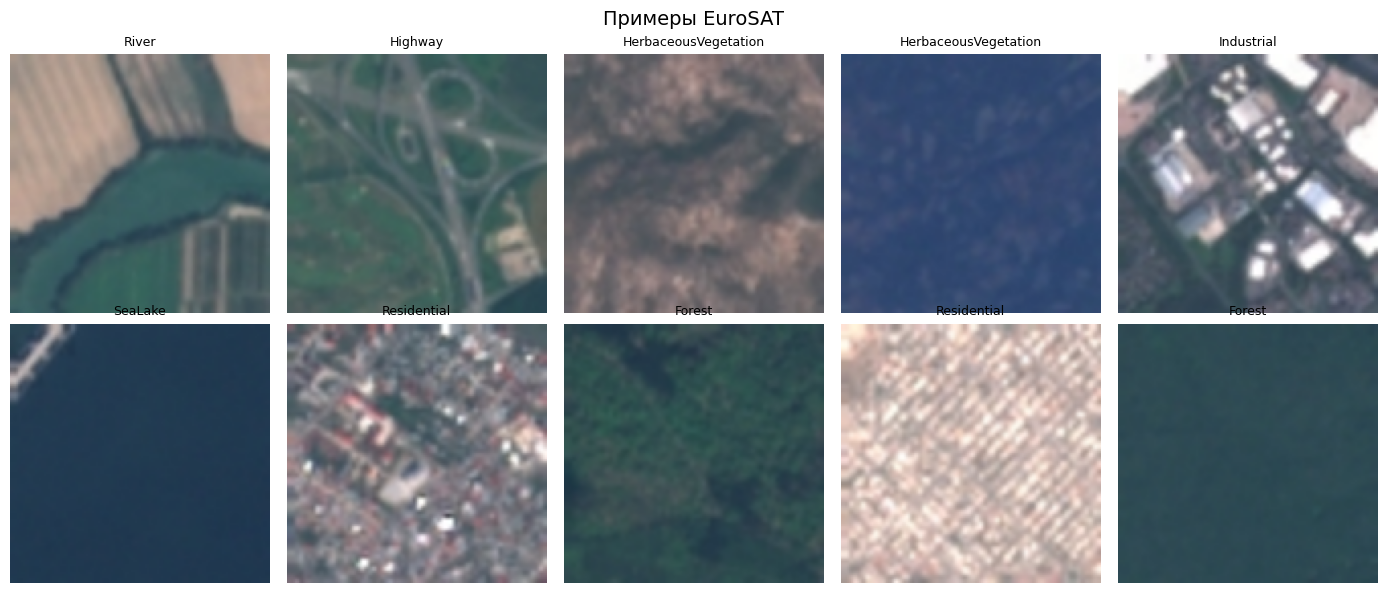

In [ ]:
plt.figure(figsize=(14, 6))
for images, labels in train_ds_raw.take(1):
    for i in range(10):
        ax = plt.subplot(2, 5, i + 1)
        plt.imshow(images[i].numpy().astype('uint8'))
        plt.title(class_names[labels[i]], fontsize=9)
        plt.axis('off')
plt.suptitle('Примеры EuroSAT', fontsize=14)
plt.tight_layout()
plt.show()

### **3.2. Выбор архитектуры нейронной сети:**
  * Выберите архитектуру нейронной сети, основанную на трансферном обучении, например, ResNet50, VGG16 или InceptionV3 ([полный список](https://keras.io/api/applications/)).
  * Загрузите предобученную модель выбранной архитектуры.


In [ ]:
base_resnet = tf.keras.applications.ResNet50(
    include_top=False,
    input_shape=(IMG_HEIGHT, IMG_WIDTH, 3),
    pooling='avg',
    weights='imagenet'
)
base_resnet.trainable = False

print(f"Всего слоёв в ResNet50: {len(base_resnet.layers)}")
base_resnet.summary()

Всего слоёв в ResNet50: 176


Model: "resnet50"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                  ┃ Output Shape              ┃         Param # ┃ Connected to               ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━┩
│ input_layer_8 (InputLayer)    │ (None, 128, 128, 3)       │               0 │ -                          │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ conv1_pad (ZeroPadding2D)     │ (None, 134, 134, 3)       │               0 │ input_layer_8[0][0]        │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ conv1_conv (Conv2D)           │ (None, 64, 64, 64)        │           9,472 │ conv1_pad[0][0]            │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ conv1_bn (BatchNormalization) │ (None, 64, 64, 64)        │             256 │ conv1_conv[0][0]           │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ conv1_relu (Activation)       │ (None, 64, 64, 64)        │               0 │ conv1_bn[0][0]             │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ pool1_pad (ZeroPadding2D)     │ (None, 66, 66, 64)        │               0 │ conv1_relu[0][0]           │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ pool1_pool (MaxPooling2D)     │ (None, 32, 32, 64)        │               0 │ pool1_pad[0][0]            │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ conv2_block1_1_conv (Conv2D)  │ (None, 32, 32, 64)        │           4,160 │ pool1_pool[0][0]           │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ conv2_block1_1_bn             │ (None, 32, 32, 64)        │             256 │ conv2_block1_1_conv[0][0]  │
│ (BatchNormalization)          │                           │                 │                            │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ conv2_block1_1_relu           │ (None, 32, 32, 64)        │               0 │ conv2_block1_1_bn[0][0]    │
│ (Activation)                  │                           │                 │                            │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ conv2_block1_2_conv (Conv2D)  │ (None, 32, 32, 64)        │          36,928 │ conv2_block1_1_relu[0][0]  │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ conv2_block1_2_bn             │ (None, 32, 32, 64)        │             256 │ conv2_block1_2_conv[0][0]  │
│ (BatchNormalization)          │                           │                 │                            │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ conv2_block1_2_relu           │ (None, 32, 32, 64)        │               0 │ conv2_block1_2_bn[0][0]    │
│ (Activation)                  │                           │                 │                            │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ conv2_block1_0_conv (Conv2D)  │ (None, 32, 32, 256)       │          16,640 │ pool1_pool[0][0]           │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ conv2_block1_3_conv (Conv2D)  │ (None, 32, 32, 256)       │          16,640 │ conv2_block1_2_relu[0][0]  │
├───────────────────────────────┼───────────────────────────┼───────────────

 Total params: 23,587,712 (89.98 MB)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 23,587,712 (89.98 MB)

In [ ]:
base_vgg = tf.keras.applications.VGG16(
    include_top=False,
    input_shape=(IMG_HEIGHT, IMG_WIDTH, 3),
    pooling='avg',
    weights='imagenet'
)
base_vgg.trainable = False

print(f"Всего слоёв в VGG16: {len(base_vgg.layers)}")
base_vgg.summary()

Всего слоёв в VGG16: 20


Model: "vgg16"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ input_layer_9 (InputLayer)           │ (None, 128, 128, 3)         │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ block1_conv1 (Conv2D)                │ (None, 128, 128, 64)        │           1,792 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ block1_conv2 (Conv2D)                │ (None, 128, 128, 64)        │          36,928 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ block1_pool (MaxPooling2D)           │ (None, 64, 64, 64)          │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ block2_conv1 (Conv2D)                │ (None, 64, 64, 128)         │          73,856 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ block2_conv2 (Conv2D)                │ (None, 64, 64, 128)         │         147,584 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ block2_pool (MaxPooling2D)           │ (None, 32, 32, 128)         │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ block3_conv1 (Conv2D)                │ (None, 32, 32, 256)         │         295,168 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ block3_conv2 (Conv2D)                │ (None, 32, 32, 256)         │         590,080 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ block3_conv3 (Conv2D)                │ (None, 32, 32, 256)         │         590,080 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ block3_pool (MaxPooling2D)           │ (None, 16, 16, 256)         │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ block4_conv1 (Conv2D)                │ (None, 16, 16, 512)         │       1,180,160 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ block4_conv2 (Conv2D)                │ (None, 16, 16, 512)         │       2,359,808 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ block4_conv3 (Conv2D)                │ (None, 16, 16, 512)         │       2,359,808 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ block4_pool (MaxPooling2D)           │ (None, 8, 8, 512)           │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ block5_conv1 (Conv2D)                │ (None, 8, 8, 512)           │       2,359,808 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ block5_conv2 (Conv2D)                │ (None, 8, 8, 512)           │       2,359,808 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ block5_conv3 (Conv2D)                │ (None, 8, 8, 512)           │       2,359,808 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ block5_pool (MaxPooling2D)           │ (None, 4, 4, 512)           │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ global_average_pooling2d_2           │ (None, 512)                 │               0 │
│ (GlobalAveragePooling2D)             │                             │                 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 14,714,688 (56.13 MB)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 14,714,688 (56.13 MB)

### **3.3. Дообучение модели:**
  * Добавьте к предобученной модели несколько слоев для классификации изображений EuroSat.
  * Обучите модель на обучающей выборке.

In [ ]:
model_resnet = keras.Sequential([
    base_resnet,
    keras.layers.Dense(256, activation='relu'),
    keras.layers.Dropout(0.4),
    keras.layers.Dense(NUM_CLASSES, activation='softmax')
], name='ResNet50_EuroSAT')

model_resnet.compile(
    optimizer=Adam(learning_rate=1e-3),
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)
model_resnet.summary()

Model: "ResNet50_EuroSAT"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ resnet50 (Functional)                │ (None, 2048)                │      23,587,712 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_6 (Dense)                      │ (None, 256)                 │         524,544 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_3 (Dropout)                  │ (None, 256)                 │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_7 (Dense)                      │ (None, 10)                  │           2,570 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 24,114,826 (91.99 MB)

 Trainable params: 527,114 (2.01 MB)

 Non-trainable params: 23,587,712 (89.98 MB)

In [ ]:
PATH_RESNET = os.path.join(SAVE_DIR, 'eurosat_resnet50.keras')

In [ ]:
history_resnet = model_resnet.fit(
    train_ds_r,
    validation_data=val_ds_r,
    epochs=30,
    callbacks=[
        ModelCheckpoint(PATH_RESNET, monitor='val_accuracy', save_best_only=True, mode='max', verbose=1),
        EarlyStopping(monitor='val_accuracy', patience=10, restore_best_weights=True, verbose=1),
        ReduceLROnPlateau(monitor='val_accuracy', factor=0.2, patience=3, min_lr=1e-7, verbose=1)
    ]
)
print(f"ResNet50 сохранена: {PATH_RESNET}")

Epoch 1/30
1350/1350 ━━━━━━━━━━━━━━━━━━━━ 0s 147ms/step - accuracy: 0.8427 - loss: 0.5110
Epoch 1: val_accuracy improved from None to 0.93713, saving model to NN_5\eurosat_resnet50.keras

Epoch 1: finished saving model to NN_5\eurosat_resnet50.keras
1350/1350 ━━━━━━━━━━━━━━━━━━━━ 237s 169ms/step - accuracy: 0.8918 - loss: 0.3365 - val_accuracy: 0.9371 - val_loss: 0.1913 - learning_rate: 0.0010
Epoch 2/30
1350/1350 ━━━━━━━━━━━━━━━━━━━━ 0s 137ms/step - accuracy: 0.9345 - loss: 0.1984
Epoch 2: val_accuracy improved from 0.93713 to 0.94712, saving model to NN_5\eurosat_resnet50.keras

Epoch 2: finished saving model to NN_5\eurosat_resnet50.keras
1350/1350 ━━━━━━━━━━━━━━━━━━━━ 214s 156ms/step - accuracy: 0.9329 - loss: 0.2033 - val_accuracy: 0.9471 - val_loss: 0.1786 - learning_rate: 0.0010
Epoch 3/30
1350/1350 ━━━━━━━━━━━━━━━━━━━━ 0s 146ms/step - accuracy: 0.9480 - loss: 0.1560
Epoch 3: val_accuracy did not improve from 0.94712
1350/1350 ━━━━━━━━━━━━━━━━━━━━ 225s 164ms/step - accuracy: 0.9

In [ ]:
def load_best_model(path):
    model = tf.keras.models.load_model(path)
    print(f"Модель загружена: {path}")
    return model

model_resnet = load_best_model(PATH_RESNET)

Модель загружена: NN_5\eurosat_resnet50.keras


In [ ]:
model_vgg = keras.Sequential([
    base_vgg,
    keras.layers.Dense(256, activation='relu'),
    keras.layers.Dropout(0.4),
    keras.layers.Dense(NUM_CLASSES, activation='softmax')
], name='VGG16_EuroSAT')

model_vgg.compile(
    optimizer=Adam(learning_rate=1e-3),
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)
model_vgg.summary()

Model: "VGG16_EuroSAT"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ vgg16 (Functional)                   │ (None, 512)                 │      14,714,688 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_8 (Dense)                      │ (None, 256)                 │         131,328 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_4 (Dropout)                  │ (None, 256)                 │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_9 (Dense)                      │ (None, 10)                  │           2,570 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 14,848,586 (56.64 MB)

 Trainable params: 133,898 (523.04 KB)

 Non-trainable params: 14,714,688 (56.13 MB)

In [ ]:
PATH_VGG = os.path.join(SAVE_DIR, 'eurosat_vgg16.keras')

In [ ]:
history_vgg = model_vgg.fit(
    train_ds_v,
    validation_data=val_ds_v,
    epochs=30,
    callbacks=[
        ModelCheckpoint(PATH_VGG, monitor='val_accuracy', save_best_only=True, mode='max', verbose=1),
        EarlyStopping(monitor='val_accuracy', patience=10, restore_best_weights=True, verbose=1),
        ReduceLROnPlateau(monitor='val_accuracy', factor=0.2, patience=3, min_lr=1e-7, verbose=1)
    ]
)
print(f"VGG16 сохранена: {PATH_VGG}")

Epoch 1/30
1350/1350 ━━━━━━━━━━━━━━━━━━━━ 0s 239ms/step - accuracy: 0.7927 - loss: 0.7486
Epoch 1: val_accuracy improved from None to 0.92788, saving model to NN_5\eurosat_vgg16.keras

Epoch 1: finished saving model to NN_5\eurosat_vgg16.keras
1350/1350 ━━━━━━━━━━━━━━━━━━━━ 351s 257ms/step - accuracy: 0.8619 - loss: 0.4605 - val_accuracy: 0.9279 - val_loss: 0.2314 - learning_rate: 0.0010
Epoch 2/30
1350/1350 ━━━━━━━━━━━━━━━━━━━━ 0s 143ms/step - accuracy: 0.9171 - loss: 0.2538
Epoch 2: val_accuracy improved from 0.92788 to 0.92973, saving model to NN_5\eurosat_vgg16.keras

Epoch 2: finished saving model to NN_5\eurosat_vgg16.keras
1350/1350 ━━━━━━━━━━━━━━━━━━━━ 217s 160ms/step - accuracy: 0.9164 - loss: 0.2578 - val_accuracy: 0.9297 - val_loss: 0.2016 - learning_rate: 0.0010
Epoch 3/30
1350/1350 ━━━━━━━━━━━━━━━━━━━━ 0s 142ms/step - accuracy: 0.9322 - loss: 0.2086
Epoch 3: val_accuracy improved from 0.92973 to 0.93713, saving model to NN_5\eurosat_vgg16.keras

Epoch 3: finished saving mo

In [ ]:
model_vgg = load_best_model(PATH_VGG)

Модель загружена: NN_5\eurosat_vgg16.keras




### **3.4. Оценка модели:**
  * Оцените производительность модели на валидационной и тестовой выборках.
  * Сравните результаты с другими архитектурами нейронных сетей.



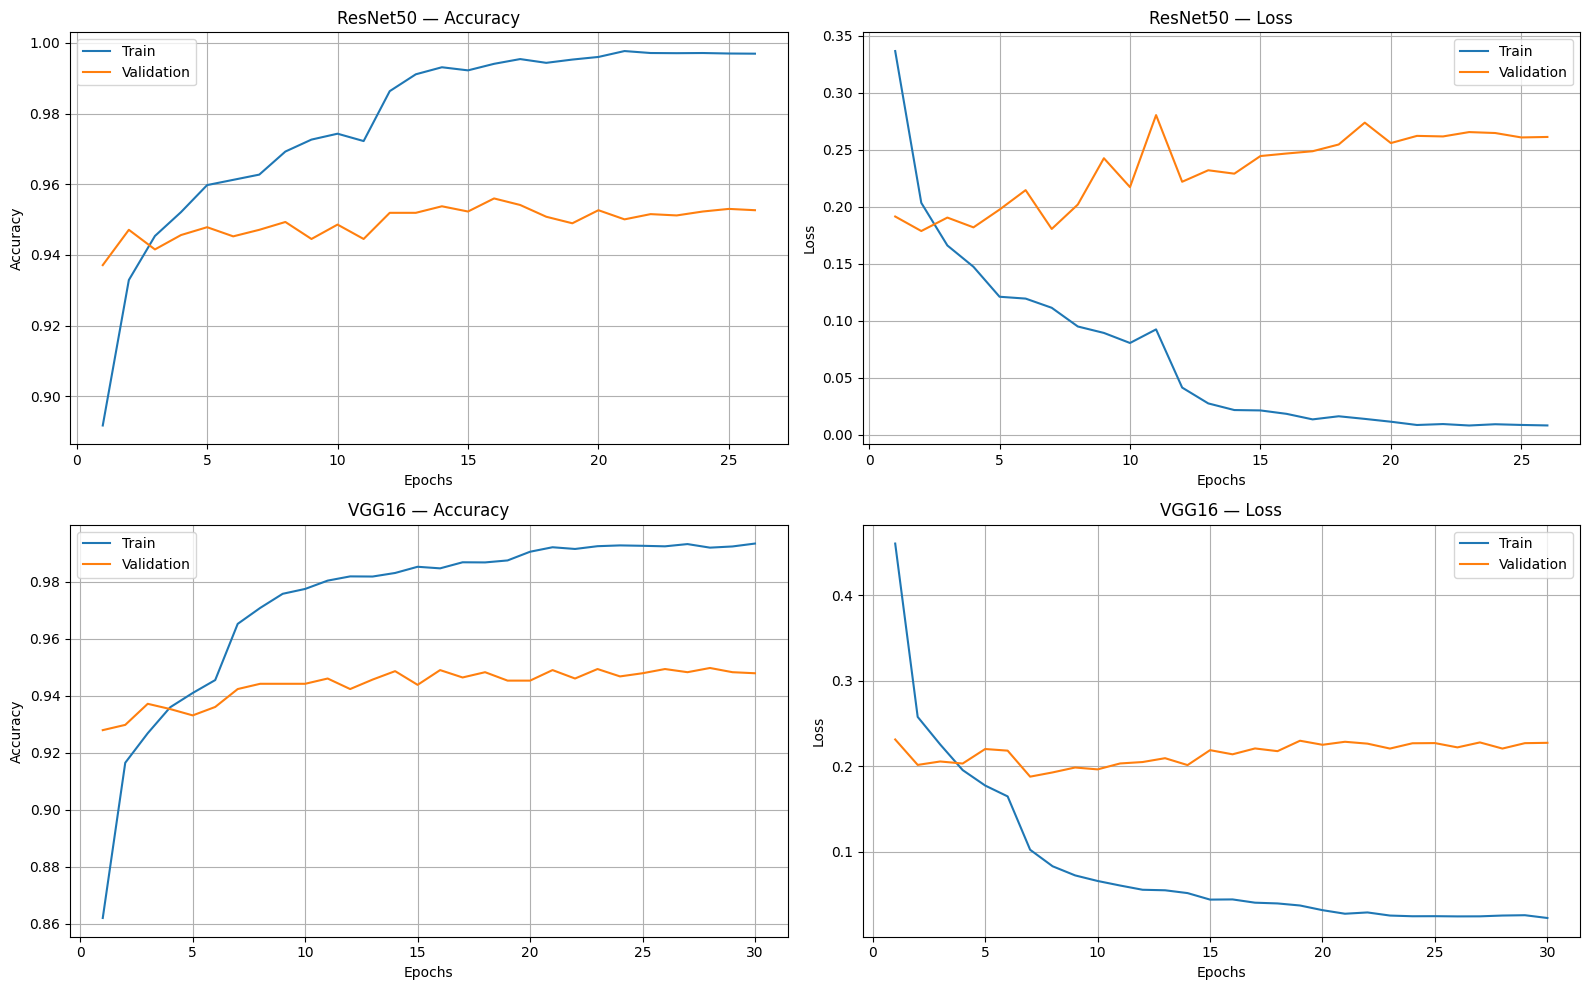

In [ ]:
fig, axes = plt.subplots(2, 2, figsize=(16, 10))
epochs_r = range(1, len(history_resnet.history['accuracy']) + 1)
epochs_v = range(1, len(history_vgg.history['accuracy']) + 1)

axes[0, 0].plot(epochs_r, history_resnet.history['accuracy'],     label='Train')
axes[0, 0].plot(epochs_r, history_resnet.history['val_accuracy'], label='Validation')
axes[0, 0].set_title('ResNet50 — Accuracy')
axes[0, 0].set_xlabel('Epochs')
axes[0, 0].set_ylabel('Accuracy')
axes[0, 0].legend()
axes[0, 0].grid(True)

axes[0, 1].plot(epochs_r, history_resnet.history['loss'],     label='Train')
axes[0, 1].plot(epochs_r, history_resnet.history['val_loss'], label='Validation')
axes[0, 1].set_title('ResNet50 — Loss')
axes[0, 1].set_xlabel('Epochs')
axes[0, 1].set_ylabel('Loss')
axes[0, 1].legend()
axes[0, 1].grid(True)

axes[1, 0].plot(epochs_v, history_vgg.history['accuracy'],     label='Train')
axes[1, 0].plot(epochs_v, history_vgg.history['val_accuracy'], label='Validation')
axes[1, 0].set_title('VGG16 — Accuracy')
axes[1, 0].set_xlabel('Epochs')
axes[1, 0].set_ylabel('Accuracy')
axes[1, 0].legend()
axes[1, 0].grid(True)

axes[1, 1].plot(epochs_v, history_vgg.history['loss'],     label='Train')
axes[1, 1].plot(epochs_v, history_vgg.history['val_loss'], label='Validation')
axes[1, 1].set_title('VGG16 — Loss')
axes[1, 1].set_xlabel('Epochs')
axes[1, 1].set_ylabel('Loss')
axes[1, 1].legend()
axes[1, 1].grid(True)

plt.tight_layout()
plt.show()

In [ ]:
val_loss_r,  val_acc_r  = model_resnet.evaluate(val_ds_r,  verbose=0)
test_loss_r, test_acc_r = model_resnet.evaluate(test_ds_r, verbose=0)

val_loss_v,  val_acc_v  = model_vgg.evaluate(val_ds_v,  verbose=0)
test_loss_v, test_acc_v = model_vgg.evaluate(test_ds_v, verbose=0)

print(f"\n{'Модель':<12} {'Val Acc':>10} {'Val Loss':>10} {'Test Acc':>10} {'Test Loss':>10}")
print('-' * 54)
print(f"{'ResNet50':<12} {val_acc_r:>10.4f} {val_loss_r:>10.4f} {test_acc_r:>10.4f} {test_loss_r:>10.4f}")
print(f"{'VGG16':<12} {val_acc_v:>10.4f} {val_loss_v:>10.4f} {test_acc_v:>10.4f} {test_loss_v:>10.4f}")


Модель          Val Acc   Val Loss   Test Acc  Test Loss
------------------------------------------------------
ResNet50         0.9549     0.2485     0.9596     0.1966
VGG16            0.9482     0.2268     0.9447     0.2205


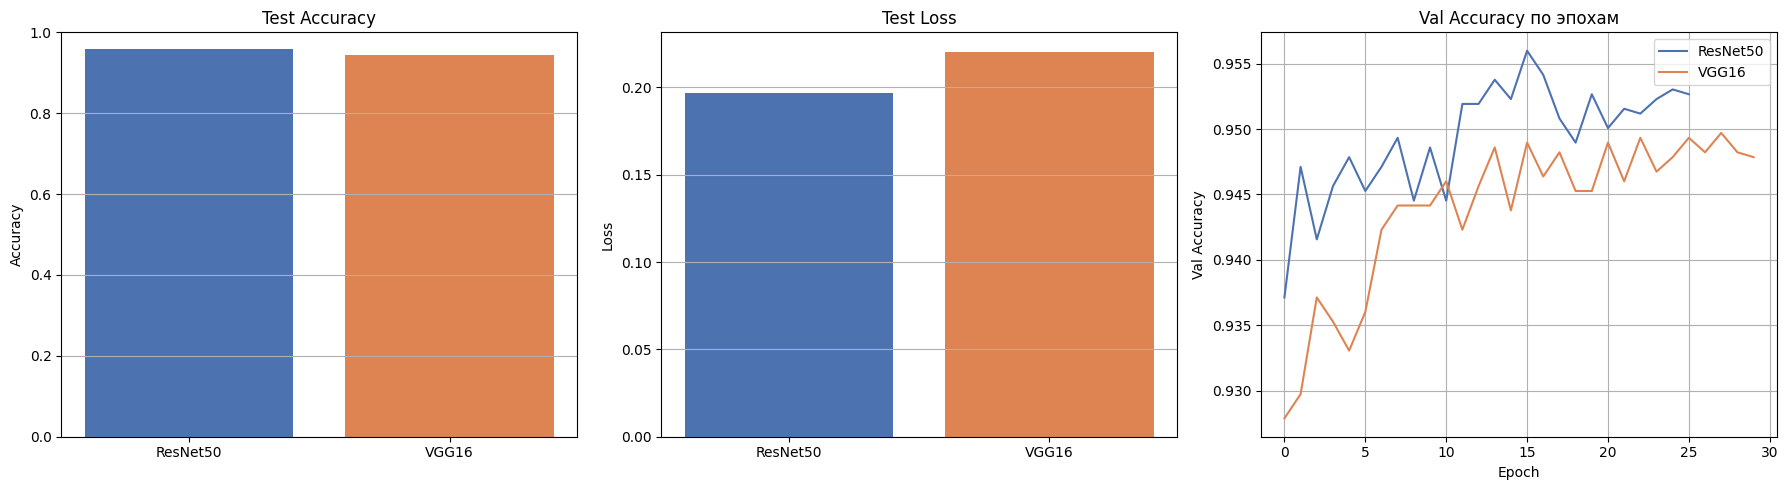

In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
model_names = ['ResNet50', 'VGG16']
test_accs   = [test_acc_r,  test_acc_v]
test_losses = [test_loss_r, test_loss_v]
colors      = ['#4C72B0', '#DD8452']

axes[0].bar(model_names, test_accs, color=colors)
axes[0].set_title('Test Accuracy')
axes[0].set_ylabel('Accuracy')
axes[0].set_ylim(0, 1)
axes[0].grid(axis='y')

axes[1].bar(model_names, test_losses, color=colors)
axes[1].set_title('Test Loss')
axes[1].set_ylabel('Loss')
axes[1].grid(axis='y')

axes[2].plot(history_resnet.history['val_accuracy'], label='ResNet50', color=colors[0])
axes[2].plot(history_vgg.history['val_accuracy'],    label='VGG16',    color=colors[1])
axes[2].set_title('Val Accuracy по эпохам')
axes[2].set_xlabel('Epoch')
axes[2].set_ylabel('Val Accuracy')
axes[2].legend()
axes[2].grid(True)

plt.tight_layout()
plt.show()

Лучшая модель: ResNet50 (Val Accuracy: 0.9549)
Всего примеров в тесте: 2696
Уникальные классы в y_true: [0 1 2 3 4 5 6 7 8 9]
Уникальные классы в y_pred: [0 1 2 3 4 5 6 7 8 9]
                      precision    recall  f1-score   support

          AnnualCrop       0.96      0.93      0.95       288
              Forest       0.99      0.98      0.99       310
HerbaceousVegetation       0.95      0.97      0.96       306
             Highway       0.91      0.91      0.91       244
          Industrial       0.98      0.98      0.98       252
             Pasture       0.95      0.95      0.95       177
       PermanentCrop       0.92      0.94      0.93       246
         Residential       0.98      0.99      0.98       286
               River       0.94      0.95      0.94       279
             SeaLake       1.00      1.00      1.00       308

            accuracy                           0.96      2696
           macro avg       0.96      0.96      0.96      2696
        weighted

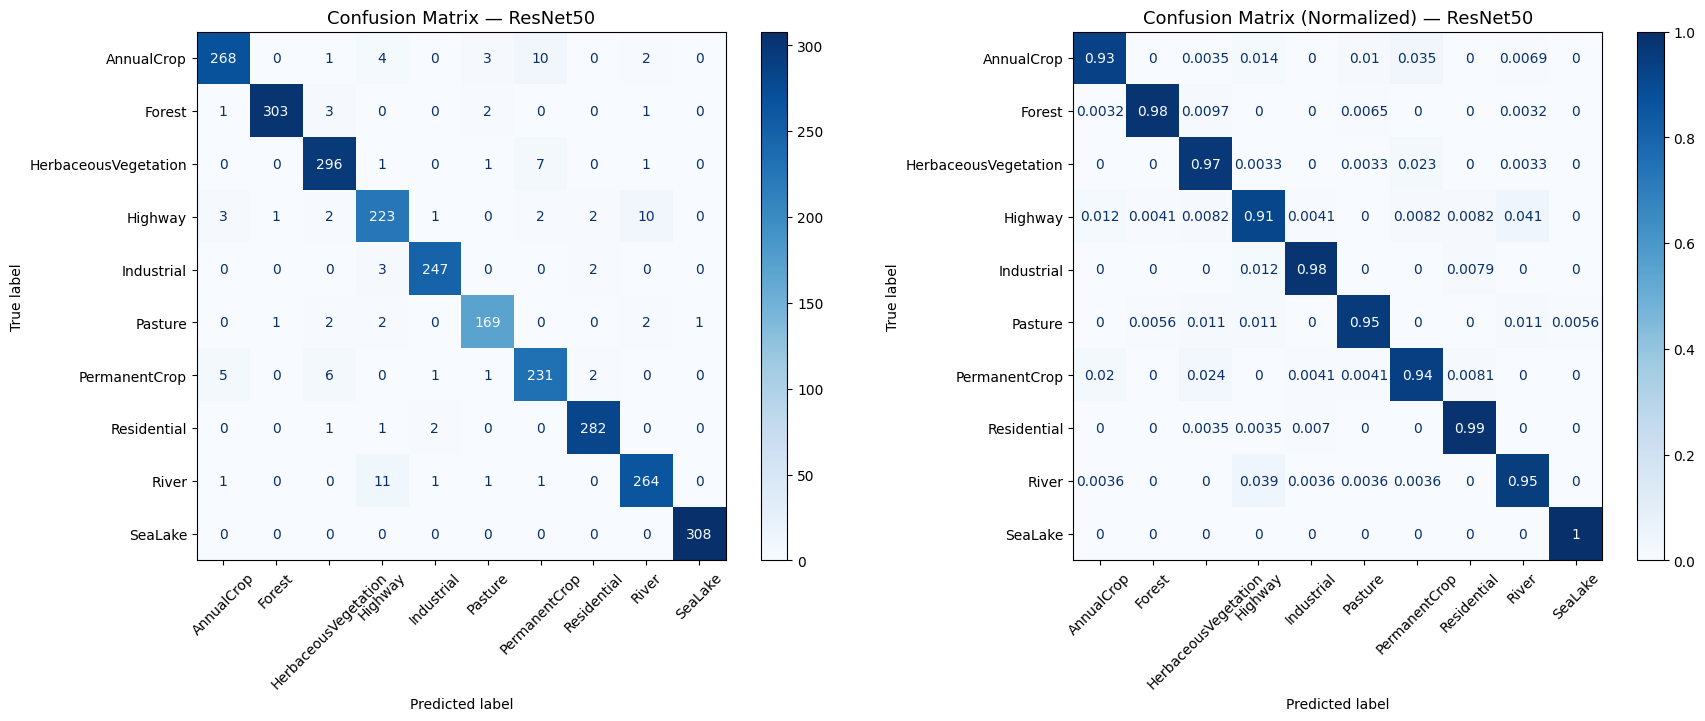

In [ ]:
if val_acc_r >= val_acc_v:
    best_model = model_resnet
    best_test_ds = test_ds_r
    best_name = 'ResNet50'
else:
    best_model = model_vgg
    best_test_ds = test_ds_v
    best_name = 'VGG16'

print(f"Лучшая модель: {best_name} (Val Accuracy: {max(val_acc_r, val_acc_v):.4f})")

y_true, y_pred = [], []
for images, labels in best_test_ds:
    preds = best_model.predict(images, verbose=0)
    y_pred.extend(np.argmax(preds, axis=1))
    y_true.extend(labels.numpy())

y_true = np.array(y_true)
y_pred = np.array(y_pred)

print(f"Всего примеров в тесте: {len(y_true)}")
print(f"Уникальные классы в y_true: {np.unique(y_true)}")
print(f"Уникальные классы в y_pred: {np.unique(y_pred)}")

present_labels = np.unique(y_true)
present_names  = [class_names[i] for i in present_labels]

print(classification_report(y_true, y_pred, labels=present_labels, target_names=present_names))

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(18, 7))
ConfusionMatrixDisplay.from_predictions(
    y_true, y_pred, display_labels=present_names, cmap='Blues', ax=ax1)
ax1.set_title(f'Confusion Matrix — {best_name}', fontsize=13)
ax1.tick_params(axis='x', rotation=45)
ax1.grid(False)

ConfusionMatrixDisplay.from_predictions(
    y_true, y_pred, display_labels=present_names, cmap='Blues', normalize='true', ax=ax2)
ax2.set_title(f'Confusion Matrix (Normalized) — {best_name}', fontsize=13)
ax2.tick_params(axis='x', rotation=45)
ax2.grid(False)

plt.tight_layout()
plt.show()

### **3.5. Анализ результатов:**
  * Проанализируйте влияние различных параметров на производительность модели, таких как:
      * Количество эпох обучения
      * Размер пакета
      * Функция активации
      * Оптимизатор
      * Регуляризация

-----------------------------------------
**Ваш вывод**
-----------------------------------------


### Количество эпох обучения

ResNet50 завершил обучение на **эпохе 26** (лучшие веса — эпоха 16), VGG16 дошёл до полного лимита в **30 эпох** (лучшие веса — эпоха 28). Это показывает принципиальное различие в динамике: ResNet50 быстро достиг потолка качества и затем стагнировал (val_accuracy «застыла» около 0.955 с эпохи 16), тогда как VGG16 медленно, но продолжал улучшаться почти до конца. Применение `EarlyStopping(patience=10)` оправдало себя для ResNet50 — лишние 10 эпох после лучшей не дали прироста, но и не ухудшили результат благодаря `restore_best_weights=True`.

### Размер пакета (Batch Size = 16)

Batch size 16 при датасете в 21 600 обучающих изображений даёт **1 350 шагов на эпоху**. Небольшой батч обеспечивает более частые обновления весов и шумовую регуляризацию — это особенно полезно на спутниковых снимках, где внутриклассовая вариативность высока (например, класс `Highway` получил наименьший f1-score = 0.91, поскольку дороги на снимках Sentinel-2 визуально перекрываются с `Residential` и `River`). Увеличение батча до 32–64 ускорило бы обучение, но могло снизить качество обобщения.

### Функция активации

В добавленной головной части обеих моделей использовалась **ReLU** для скрытого слоя (Dense 256) и **Softmax** для выходного (Dense 10). ReLU не страдает от затухания градиента и вычислительно эффективна. Предобученные части ResNet50 и VGG16 содержат собственные активации (ReLU, BatchNorm в ResNet50), заданные исходной архитектурой — их изменение при transfer learning не практикуется.

### Оптимизатор и Learning Rate

Обе модели обучались с **Adam(lr=1e-3)** и `ReduceLROnPlateau(factor=0.2, patience=3)`. У ResNet50 lr снизился трижды: 1e-3 → 2e-4 → 4e-5 → 8e-6 к моменту остановки. У VGG16 — аналогично, но снижения начались позже (с эпохи ~15). Адаптивное снижение lr позволило «дожать» точность в финальных эпохах: у VGG16 лучшая эпоха (28) пришлась уже при минимальном lr, когда шаги стали очень мелкими и модель аккуратно довела val_accuracy с 0.9493 до 0.9497.

### Регуляризация

Применялся **Dropout(0.4)** перед выходным слоем. Без него на EuroSAT при замороженном backbone переобучение маловероятно (обучается только головная часть), однако Dropout всё равно полезен: train_accuracy у обеих моделей к концу обучения достигла 0.996–0.997, тогда как val_accuracy остановилась на 0.948–0.955 — разрыв в ~4% свидетельствует о лёгком переобучении головной части. Увеличение Dropout до 0.5 могло бы его сократить.

### Сравнение архитектур

| Метрика | ResNet50 | VGG16 |
|---|---|---|
| Эпох обучения | 26 (лучшая: 16) | 30 (лучшая: 28) |
| Val Accuracy | **0.9549** | 0.9482 |
| Test Accuracy | **0.9596** | 0.9447 |
| Test Loss | **0.1966** | 0.2205 |
| Лучший класс | SeaLake (f1=1.00) | — |
| Худший класс | Highway (f1=0.91) | — |

ResNet50 превзошёл VGG16 по всем метрикам. Ключевые причины: остаточные связи (skip connections) устраняют деградацию градиента в глубокой сети, Batch Normalization стабилизирует обучение, а глобальный пулинг (`pooling='avg'`) сжимает признаки эффективнее, чем плоский Flatten в VGG16. Класс `SeaLake` распознаётся идеально (f1=1.00) — водные объекты однородны и ярко выделяются на мультиспектральных снимках. Наибольшую трудность представляет `Highway` (f1=0.91) из-за визуального сходства дорог с городской застройкой и руслами рек.